<a href="https://colab.research.google.com/github/yaraabdalkreemismaiel-art/SmartDeskAI/blob/main/notebooks/posture_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`**تجهيز بيئة العمل**`

In [1]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
import cv2
import mediapipe as mp

print("OpenCV version:", cv2.__version__)
print("MediaPipe imported successfully")

OpenCV version: 5.0.0
MediaPipe imported successfully


In [3]:
import cv2
import matplotlib.pyplot as plt

print("Libraries imported")

Libraries imported


`**تشغيل صورة واحدة**`

In [4]:
image = cv2.imread("person sitting on chair.jpg")

print(type(image))
print(image.shape)

<class 'numpy.ndarray'>
(368, 543, 3)


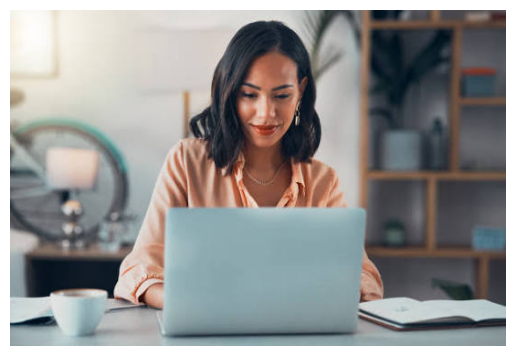

In [5]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off");

`**  MediaPipe Poseاستخدام**`
(Body Landmarks)اكتشاف جسم الانسان واستخراج نقاط الجسم

In [6]:
import sys
import mediapipe as mp

print("Python:", sys.version)
print("MediaPipe:", getattr(mp, "__version__", "unknown"))
print("MediaPipe path:", mp.__file__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
MediaPipe: 1.0.0
MediaPipe path: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py


In [7]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)

print("Tasks available:", hasattr(mp, "tasks"))

MediaPipe version: 1.0.0
Tasks available: True


In [8]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("Pose Landmarker API is available")

Pose Landmarker API is available


In [9]:
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

In [10]:
import os

print(os.path.exists("pose_landmarker_full.task"))

True


Pose Landmarkerانشاء

In [11]:
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker_full.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options
)

landmarker = vision.PoseLandmarker.create_from_options(options)

print("Pose Landmarker is ready")

Pose Landmarker is ready


In [12]:
import os

print(os.listdir())

['.config', 'person sitting on chair.jpg', 'pose_landmarker_full.task', '.ipynb_checkpoints', 'sample_data']


In [13]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image converted to RGB")

Image converted to RGB


In [14]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

print("Image converted to MediaPipe format")

Image converted to MediaPipe format


In [15]:
result = landmarker.detect(mp_image)

print("Inference completed")

Inference completed


In [16]:
print("Number of detected people:", len(result.pose_landmarks))

Number of detected people: 1


In [17]:
landmarks = result.pose_landmarks[0]

print("Number of landmarks:", len(landmarks))

Number of landmarks: 33


    على الصورةlandMarks 33 رسم الـ

In [18]:
from mediapipe.tasks.python.vision import drawing_utils

In [19]:
height, width, _ = image.shape

print("Width:", width)
print("Height:", height)

Width: 543
Height: 368


In [20]:
import cv2
import matplotlib.pyplot as plt

image_with_landmarks = image.copy()

for landmark in landmarks:
    x = int(landmark.x * width)
    y = int(landmark.y * height)

    cv2.circle(
        image_with_landmarks,
        (x, y),
        5,
        (0, 255, 0),
        -1
    )

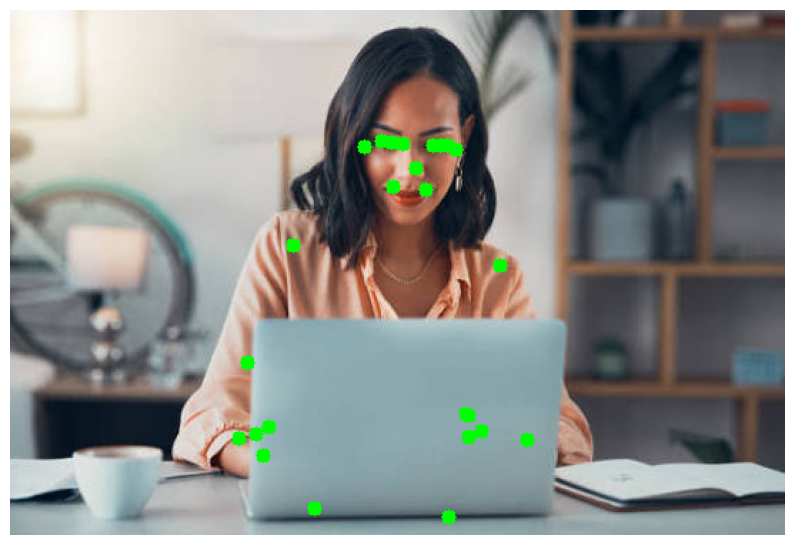

In [21]:
plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(image_with_landmarks, cv2.COLOR_BGR2RGB)
)

plt.axis("off");

In [22]:
from mediapipe.tasks.python.vision import PoseLandmark

In [23]:
for landmark in PoseLandmark:
    print(landmark.value, landmark.name)

0 NOSE
1 LEFT_EYE_INNER
2 LEFT_EYE
3 LEFT_EYE_OUTER
4 RIGHT_EYE_INNER
5 RIGHT_EYE
6 RIGHT_EYE_OUTER
7 LEFT_EAR
8 RIGHT_EAR
9 MOUTH_LEFT
10 MOUTH_RIGHT
11 LEFT_SHOULDER
12 RIGHT_SHOULDER
13 LEFT_ELBOW
14 RIGHT_ELBOW
15 LEFT_WRIST
16 RIGHT_WRIST
17 LEFT_PINKY
18 RIGHT_PINKY
19 LEFT_INDEX
20 RIGHT_INDEX
21 LEFT_THUMB
22 RIGHT_THUMB
23 LEFT_HIP
24 RIGHT_HIP
25 LEFT_KNEE
26 RIGHT_KNEE
27 LEFT_ANKLE
28 RIGHT_ANKLE
29 LEFT_HEEL
30 RIGHT_HEEL
31 LEFT_FOOT_INDEX
32 RIGHT_FOOT_INDEX


In [24]:
nose = landmarks[0]

print("Nose X:", nose.x)
print("Nose Y:", nose.y)
print("Nose Z:", nose.z)
print("Nose visibility:", nose.visibility)

Nose X: 0.5234537720680237
Nose Y: 0.3033432364463806
Nose Z: -0.563235342502594
Nose visibility: 0.9997226595878601


In [25]:
left_shoulder = landmarks[11]

print("Left Shoulder X:", left_shoulder.x)
print("Left Shoulder Y:", left_shoulder.y)
print("Left Shoulder Z:", left_shoulder.z)
print("Left Shoulder visibility:", left_shoulder.visibility)

Left Shoulder X: 0.6320062279701233
Left Shoulder Y: 0.48655378818511963
Left Shoulder Z: -0.16805066168308258
Left Shoulder visibility: 0.999699592590332


In [26]:
print("Number of landmarks:", len(landmarks))

for i, landmark in enumerate(landmarks):
    print(
        i,
        "x =", round(landmark.x, 3),
        "y =", round(landmark.y, 3),
        "z =", round(landmark.z, 3),
        "visibility =", round(landmark.visibility, 3)
    )

Number of landmarks: 33
0 x = 0.523 y = 0.303 z = -0.563 visibility = 1.0
1 x = 0.545 y = 0.261 z = -0.546 visibility = 1.0
2 x = 0.555 y = 0.26 z = -0.546 visibility = 1.0
3 x = 0.564 y = 0.26 z = -0.547 visibility = 1.0
4 x = 0.507 y = 0.257 z = -0.55 visibility = 1.0
5 x = 0.492 y = 0.254 z = -0.55 visibility = 1.0
6 x = 0.479 y = 0.252 z = -0.55 visibility = 1.0
7 x = 0.576 y = 0.269 z = -0.336 visibility = 1.0
8 x = 0.458 y = 0.262 z = -0.35 visibility = 1.0
9 x = 0.537 y = 0.345 z = -0.474 visibility = 1.0
10 x = 0.495 y = 0.338 z = -0.479 visibility = 1.0
11 x = 0.632 y = 0.487 z = -0.168 visibility = 1.0
12 x = 0.366 y = 0.45 z = -0.158 visibility = 1.0
13 x = 0.667 y = 0.818 z = -0.188 visibility = 0.915
14 x = 0.307 y = 0.672 z = -0.096 visibility = 0.772
15 x = 0.608 y = 0.803 z = -0.429 visibility = 0.389
16 x = 0.334 y = 0.796 z = -0.263 visibility = 0.229
17 x = 0.592 y = 0.815 z = -0.481 visibility = 0.215
18 x = 0.328 y = 0.849 z = -0.299 visibility = 0.175
19 x = 0.593

In [27]:
landmark_names = [
    "Nose",
    "Left Eye Inner",
    "Left Eye",
    "Left Eye Outer",
    "Right Eye Inner",
    "Right Eye",
    "Right Eye Outer",
    "Left Ear",
    "Right Ear",
    "Mouth Left",
    "Mouth Right",
    "Left Shoulder",
    "Right Shoulder",
    "Left Elbow",
    "Right Elbow",
    "Left Wrist",
    "Right Wrist",
    "Left Pinky",
    "Right Pinky",
    "Left Index",
    "Right Index",
    "Left Thumb",
    "Right Thumb",
    "Left Hip",
    "Right Hip",
    "Left Knee",
    "Right Knee",
    "Left Ankle",
    "Right Ankle",
    "Left Heel",
    "Right Heel",
    "Left Foot Index",
    "Right Foot Index"
]

for i in [0, 11, 12, 13, 14, 23, 24, 25, 26]:
    lm = landmarks[i]
    print(
        f"{i:2d} | {landmark_names[i]:15s} | "
        f"x={lm.x:.3f} | y={lm.y:.3f} | "
        f"z={lm.z:.3f} | visibility={lm.visibility:.3f}"
    )

 0 | Nose            | x=0.523 | y=0.303 | z=-0.563 | visibility=1.000
11 | Left Shoulder   | x=0.632 | y=0.487 | z=-0.168 | visibility=1.000
12 | Right Shoulder  | x=0.366 | y=0.450 | z=-0.158 | visibility=1.000
13 | Left Elbow      | x=0.667 | y=0.818 | z=-0.188 | visibility=0.915
14 | Right Elbow     | x=0.307 | y=0.672 | z=-0.096 | visibility=0.772
23 | Left Hip        | x=0.566 | y=0.966 | z=-0.009 | visibility=0.940
24 | Right Hip       | x=0.393 | y=0.950 | z=0.011 | visibility=0.944
25 | Left Knee       | x=0.576 | y=1.351 | z=0.212 | visibility=0.284
26 | Right Knee      | x=0.404 | y=1.350 | z=0.278 | visibility=0.160


features: 1)المسافة بين الكتفين

In [28]:
import math

left_shoulder = landmarks[11]
right_shoulder = landmarks[12]

shoulder_distance = math.sqrt(
    (right_shoulder.x - left_shoulder.x)**2 +
    (right_shoulder.y - left_shoulder.y)**2
)

print("Shoulder distance:", shoulder_distance)

Shoulder distance: 0.26895313964952156


features: 2)المسافة بين الوركين

In [29]:
left_hip = landmarks[23]
right_hip = landmarks[24]

hip_distance = math.sqrt(
    (right_hip.x - left_hip.x)**2 +
    (right_hip.y - left_hip.y)**2
)

print("Hip distance:", hip_distance)

Hip distance: 0.17400016369232035


نسبة الكتفين الى الوركين(3

In [30]:
shoulder_hip_ratio = shoulder_distance / hip_distance

print("Shoulder/Hip ratio:", shoulder_hip_ratio)

Shoulder/Hip ratio: 1.5457062449958605


4)ميل الكتفين

In [31]:
shoulder_y_difference = abs(
    left_shoulder.y - right_shoulder.y
)

print("Shoulder Y difference:", shoulder_y_difference)

Shoulder Y difference: 0.0364510715007782


In [32]:
shoulder_y_difference = abs(
    left_shoulder.y - right_shoulder.y
)

print("Shoulder Y difference:", shoulder_y_difference)

Shoulder Y difference: 0.0364510715007782


In [33]:
# Get the center point between the two shoulders

shoulder_center_x = (
    left_shoulder.x + right_shoulder.x
) / 2

shoulder_center_y = (
    left_shoulder.y + right_shoulder.y
) / 2

print("Shoulder center X:", shoulder_center_x)
print("Shoulder center Y:", shoulder_center_y)

Shoulder center X: 0.49877043068408966
Shoulder center Y: 0.46832825243473053


In [34]:
# Difference between the nose and the shoulder center

head_shoulder_dx = nose.x - shoulder_center_x
head_shoulder_dy = nose.y - shoulder_center_y

print("Head-Shoulder X difference:", head_shoulder_dx)
print("Head-Shoulder Y difference:", head_shoulder_dy)

Head-Shoulder X difference: 0.02468334138393402
Head-Shoulder Y difference: -0.16498501598834991


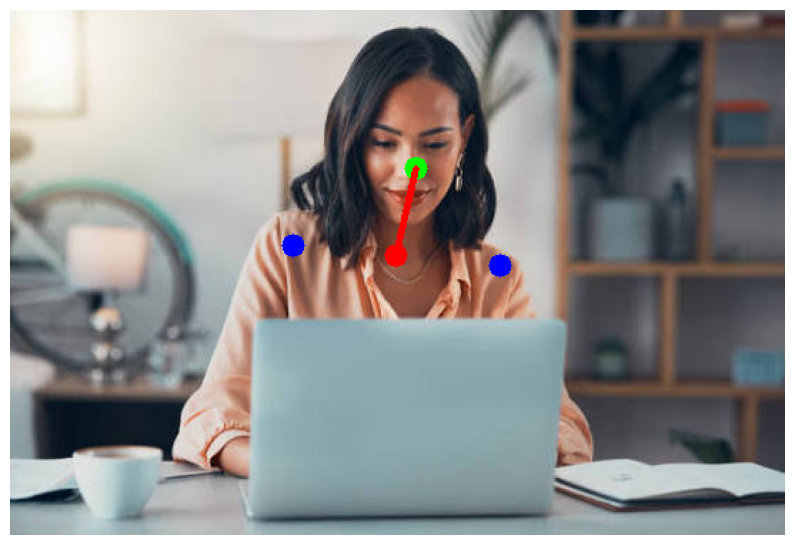

In [35]:
import cv2
import matplotlib.pyplot as plt

# Create a copy of the original image
image_visual = image.copy()

# Convert normalized coordinates to pixel coordinates
nose_x = int(nose.x * width)
nose_y = int(nose.y * height)

left_shoulder_x = int(left_shoulder.x * width)
left_shoulder_y = int(left_shoulder.y * height)

right_shoulder_x = int(right_shoulder.x * width)
right_shoulder_y = int(right_shoulder.y * height)

shoulder_center_pixel_x = int(shoulder_center_x * width)
shoulder_center_pixel_y = int(shoulder_center_y * height)

# Draw Nose
cv2.circle(
    image_visual,
    (nose_x, nose_y),
    8,
    (0, 255, 0),
    -1
)

# Draw Left Shoulder
cv2.circle(
    image_visual,
    (left_shoulder_x, left_shoulder_y),
    8,
    (255, 0, 0),
    -1
)

# Draw Right Shoulder
cv2.circle(
    image_visual,
    (right_shoulder_x, right_shoulder_y),
    8,
    (255, 0, 0),
    -1
)

# Draw Shoulder Center
cv2.circle(
    image_visual,
    (shoulder_center_pixel_x, shoulder_center_pixel_y),
    8,
    (0, 0, 255),
    -1
)

# Draw line from Nose to Shoulder Center
cv2.line(
    image_visual,
    (nose_x, nose_y),
    (shoulder_center_pixel_x, shoulder_center_pixel_y),
    (0, 0, 255),
    3
)

# Display image
plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(image_visual, cv2.COLOR_BGR2RGB)
)

plt.axis("off");